### CODE

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("talabat_enhanced_orders.csv")

df.head()
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [3]:
#1.check null values

df.isnull().sum()




Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [4]:
#2.check duplicate values

df.duplicated().sum()


0

In [5]:
#3.convert date and time columns

df['Order_Time'] = pd.to_datetime(df['Order_Time'])
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'])

df[['Order_Time', 'Delivery_Time']].head()




,Order_Time,Delivery_Time
0,2025-06-16 08:32:00,2025-06-16 09:11:00
1,2025-06-03 21:27:00,2025-06-03 22:00:00
2,2025-06-01 14:48:00,2025-06-01 15:26:00
3,2025-06-13 02:30:00,2025-06-13 03:22:00
4,2025-06-06 09:48:00,2025-06-06 10:32:00


In [6]:
#4.Creating time based Features.
df['order_hour'] = df['Order_Time'].dt.hour
df['order_day'] = df['Order_Time'].dt.day
df['order_month'] = df['Order_Time'].dt.month
df['order_weekday'] = df['Order_Time'].dt.weekday
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)




In [7]:
#5.Creating delivery duration column
df['delivery_duration_mins'] = (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60

df['delivery_duration_mins'].describe()


count    100000.000000
mean         37.520110
std          10.060876
min          15.000000
25%          30.000000
50%          38.000000
75%          45.000000
max          60.000000
Name: delivery_duration_mins, dtype: float64

In [8]:
#6.check categorical values

categorical_cols = ['Payment_Method', 'Traffic_Level', 'Order_Status', 'Driver_Vehicle']
for col in categorical_cols:
    if col in df.columns:
        print(col, df[col].value_counts())

Payment_Method Payment_Method
Cash           33528
Wallet         33250
Credit Card    33222
Name: count, dtype: int64
Traffic_Level Traffic_Level
Low       45826
High      29220
Medium    24954
Name: count, dtype: int64
Order_Status Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64
Driver_Vehicle Driver_Vehicle
Bicycle      33393
Car          33362
Motorbike    33245
Name: count, dtype: int64


In [9]:
#7.location information

location_cols = ['Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon']
df[location_cols].describe()


,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,30.119015,31.063065,30.119060,31.062971
std,1.271638,0.487754,1.271674,0.487811
min,27.160900,29.898701,27.160900,29.898706
25%,30.023110,31.008774,30.023370,31.008460
50%,30.587306,31.209099,30.587054,31.208817
75%,31.026912,31.371676,31.027112,31.371856
max,31.220099,31.521997,31.220096,31.521995


In [10]:
#8.Removing unrealistic values

df = df[df['delivery_duration_mins'] >= 0]


In [11]:
#9. Filtering only Completed orders

df = df[df['Order_Status'] == 'Delivered']

In [26]:
# 10. Create hourly time buckets
df['date_hour'] = df['Order_Time'].dt.floor('H')

# 11. Create zones using restaurant coordinates
from sklearn.cluster import KMeans

coords = df[['Restaurant_Lat', 'Restaurant_Lon']]
kmeans = KMeans(n_clusters=10, random_state=42)
df['zone'] = kmeans.fit_predict(coords)

# 12. Create demand variable
zone_demand = df.groupby(['zone', 'date_hour']).size().reset_index(name='demand')

# 13. Encode traffic level
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Traffic_Level_Encoded'] = le.fit_transform(df['Traffic_Level'])

# 14. Aggregate additional features
features_df = df.groupby(['zone', 'date_hour']).agg({
    'Quantity': 'sum',
    'Total_Price': 'sum',
    'delivery_duration_mins': 'mean',
    'Traffic_Level_Encoded': 'mean'
}).reset_index()

# 15. Merge demand and features
model_df = pd.merge(zone_demand, features_df, on=['zone', 'date_hour'], how='left')
model_df = model_df.fillna(0)

# 16. Pivot demand data
pivot_demand = model_df.pivot(index='date_hour', columns='zone', values='demand').fillna(0)

# 17. Create sequences
def create_sequences(data, seq_length=6):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

data = pivot_demand.values
X, y = create_sequences(data, seq_length=6)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 18. Create adjacency matrix
from sklearn.metrics.pairwise import euclidean_distances

zone_coords = df.groupby('zone')[['Restaurant_Lat', 'Restaurant_Lon']].mean()
dist_matrix = euclidean_distances(zone_coords)
adj_matrix = np.exp(-dist_matrix)

print("Adjacency matrix shape:", adj_matrix.shape)

# 19. Save outputs
df.to_csv("cleaned_orders.csv", index=False)
model_df.to_csv("zone_time_features.csv", index=False)
pivot_demand.to_csv("pivot_demand.csv")

C:\Users\hanna\AppData\Local\Temp\ipykernel_23192\1591959286.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['date_hour'] = df['Order_Time'].dt.floor('H')


X shape: (355, 6, 10)
y shape: (355, 10)
Adjacency matrix shape: (10, 10)


In [28]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (284, 6, 10)
X_test: (71, 6, 10)
y_train: (284, 10)
y_test: (71, 10)


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# reshape X to 2D for scaling
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [38]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_train_scaled.shape[1])
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 4.2 MB/s eta 0:01:23
   ---------------------------------------- 1.0/350.9 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 1.6/350.9 MB 2.8 MB/s eta 0:02:05
   ---------------------------------------- 1.8/350.9 MB 2.6 MB/s eta 0:02:16
   ---------------------------------------- 2.9/350.9 MB 2.8 MB/s eta 0:02:03
   ---------------------------------------- 3.9/350.9 MB 3.3 MB/s eta 0:01:47
    --------------------------------------- 5.0/350.9 MB 3.6 MB/s eta 0:01:38
    --------------------------------------- 6.0/350.9 MB 3.8 MB/s eta 0:01:32
    --------------------------------------- 7.1/350.9 MB 3.9 MB/s eta 0:01:30
    --------------------------------------- 7.9/350.9 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 8.7/350.9 MB 3.9 MB/s eta 0:01:28
   - -------------------------------------- 8.9/350.9 MB 3.9 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


C:\Users\hanna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,610 (84.41 KB)

 Trainable params: 21,610 (84.41 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.1353 - mae: 0.3047 - val_loss: 0.0461 - val_mae: 0.1700
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0473 - mae: 0.1731 - val_loss: 0.0336 - val_mae: 0.1453
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0382 - mae: 0.1545 - val_loss: 0.0323 - val_mae: 0.1430
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0367 - mae: 0.1521 - val_loss: 0.0310 - val_mae: 0.1409
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0358 - mae: 0.1499 - val_loss: 0.0313 - val_mae: 0.1414
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0351 - mae: 0.1482 - val_loss: 0.0314 - val_mae: 0.1421
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0351 - mae: 0.1490 - val_loss: 0.0317 - val_mae: 0.1416
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0347 - mae: 0.1476 - val_loss: 0.0313 - val_mae: 0.1418
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.03

In [42]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
LSTM MAE: 4.209908604957688
LSTM RMSE: 5.669922174618313


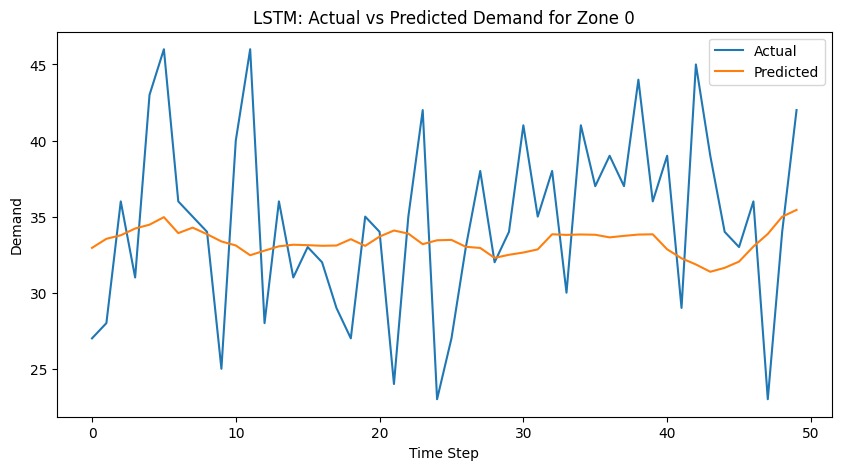

In [44]:
zone_idx = 0

plt.figure(figsize=(10,5))
plt.plot(y_test_actual[:50, zone_idx], label='Actual')
plt.plot(y_pred[:50, zone_idx], label='Predicted')
plt.title(f'LSTM: Actual vs Predicted Demand for Zone {zone_idx}')
plt.xlabel('Time Step')
plt.ylabel('Demand')
plt.legend()
plt.show()